# Mahalanobis Distance Filter for Quality Control

### Table of Contents
#### [Mahalanobis Distance Filter for Quality Control](#Mahalanobis-Distance-Filter-for-Quality-Control)
#### [Imports and Modules](#Imports-and-Modules)
#### [Sample Data](#Sample-Data)
#### [Data Processing and Visualization using seaborn](#Data-Processing-and-Visualization-using-seaborn)
#### [Mahalanobis Distance Outlier Detection](#Mahalanobis-Distance-Outlier-Detection)
#### [Filtered Plot Function](#Filtered-Plot-Function)

# Imports and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
import seaborn as sns
from matplotlib.patches import Ellipse
from typing import Tuple 
import warnings

warnings.filterwarnings("ignore")
print("Setup Complete")

Matplotlib is building the font cache; this may take a moment.


Setup Complete


# Sample Data

In [2]:
# Read csv
csv_path = "data/sample_data_7d.csv"
df_sample = pd.read_csv(csv_path)
df_sample.head()

,Pile No.,Sample 1,Sample 2,Sample 3
0,23,4170,4020,4080
1,17,4080,4210,4030
2,27,4400,4080,4730
3,63,4320,4100,4100
4,30,4330,4120,4250


# Data Processing and Visualization using seaborn

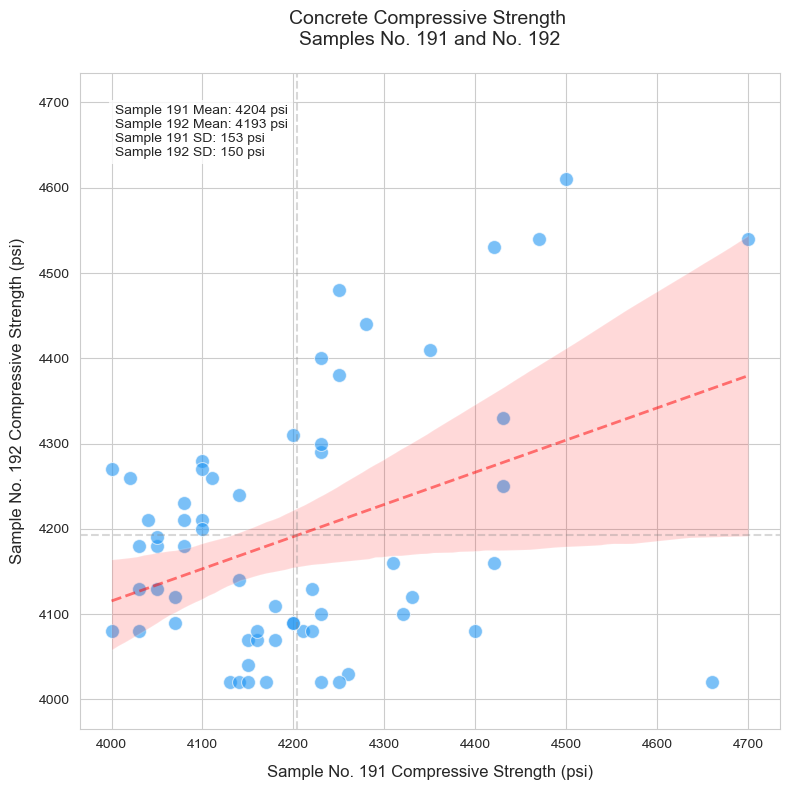

In [3]:
def process_data(data):
    """
    Processes raw data into a format suitable for plotting.
    Takes pairs of Sample 1 and Sample 2 measurements and returns them as a DataFrame.

    Args:
        data: DataFrame containing Sample 1 and Sample 2 columns

    Returns:
        DataFrame with Sample 191 and Sample 192 columns containing valid pairs
    """
    processed_data = []
    for _, row in data.iterrows():
        # Only include rows where both samples have valid measurements
        sample1 = row["Sample 1"] if not pd.isna(row["Sample 1"]) else None
        sample2 = row["Sample 2"] if not pd.isna(row["Sample 2"]) else None
        if sample1 is not None and sample2 is not None:
            processed_data.append({"Sample 191": sample1, "Sample 192": sample2})
    return pd.DataFrame(processed_data)


# ===== Plotting Functions =====


def create_strength_plot(data, save_graph=False):
    """
    Creates a scatter plot comparing compressive strength measurements between two samples.
    Includes regression line, reference lines at means, and statistical information.

    Args:
        data: DataFrame with Sample 191 and Sample 192 columns

    Returns:
        matplotlib Figure object containing the plot
    """
    # Set up the plot style and figure
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 8))

    # Create main scatter plot
    scatter = sns.scatterplot(
        data=data,
        x="Sample 191",
        y="Sample 192",
        color="#2196F3",  # Blue dots
        alpha=0.6,  # Semi-transparent
        s=100,  # Point size
    )

    # Add regression line
    sns.regplot(
        data=data,
        x="Sample 191",
        y="Sample 192",
        scatter=False,
        color="red",
        line_kws={"linestyle": "--", "linewidth": 2, "alpha": 0.5},
    )

    # Calculate means and add reference lines
    mean_x = data["Sample 191"].mean()
    mean_y = data["Sample 192"].mean()
    plt.axvline(x=mean_x, color="gray", linestyle="--", alpha=0.3)
    plt.axhline(y=mean_y, color="gray", linestyle="--", alpha=0.3)

    # Set axis limits with 5% margin
    min_val = min(data["Sample 191"].min(), data["Sample 192"].min())
    max_val = max(data["Sample 191"].max(), data["Sample 192"].max())
    margin = (max_val - min_val) * 0.05
    plt.xlim(min_val - margin, max_val + margin)
    plt.ylim(min_val - margin, max_val + margin)

    # Add title and labels
    plt.title(
        "Concrete Compressive Strength \nSamples No. 191 and No. 192",
        fontsize=14,
        pad=20,
    )
    plt.xlabel("Sample No. 191 Compressive Strength (psi)", fontsize=12, labelpad=10)
    plt.ylabel("Sample No. 192 Compressive Strength (psi)", fontsize=12, labelpad=10)

    # Add statistical information box
    stats_text = (
        f"Sample 191 Mean: {mean_x:.0f} psi\n"
        f"Sample 192 Mean: {mean_y:.0f} psi\n"
        f'Sample 191 SD: {data["Sample 191"].std():.0f} psi\n'
        f'Sample 192 SD: {data["Sample 192"].std():.0f} psi'
    )
    plt.text(
        0.05,
        0.95,
        stats_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
        fontsize=10,
        verticalalignment="top",
    )
    # Save graph
    if save_graph:
        plot.savefig("images/concrete_strength.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    return plt.gcf()


# Run main
if __name__ == "__main__":
    # Process the raw data
    data = df_sample
    processed_data = process_data(data)

    # Create and display the plot
    plot = create_strength_plot(processed_data)

# Mahalanobis Distance Outlier Detection

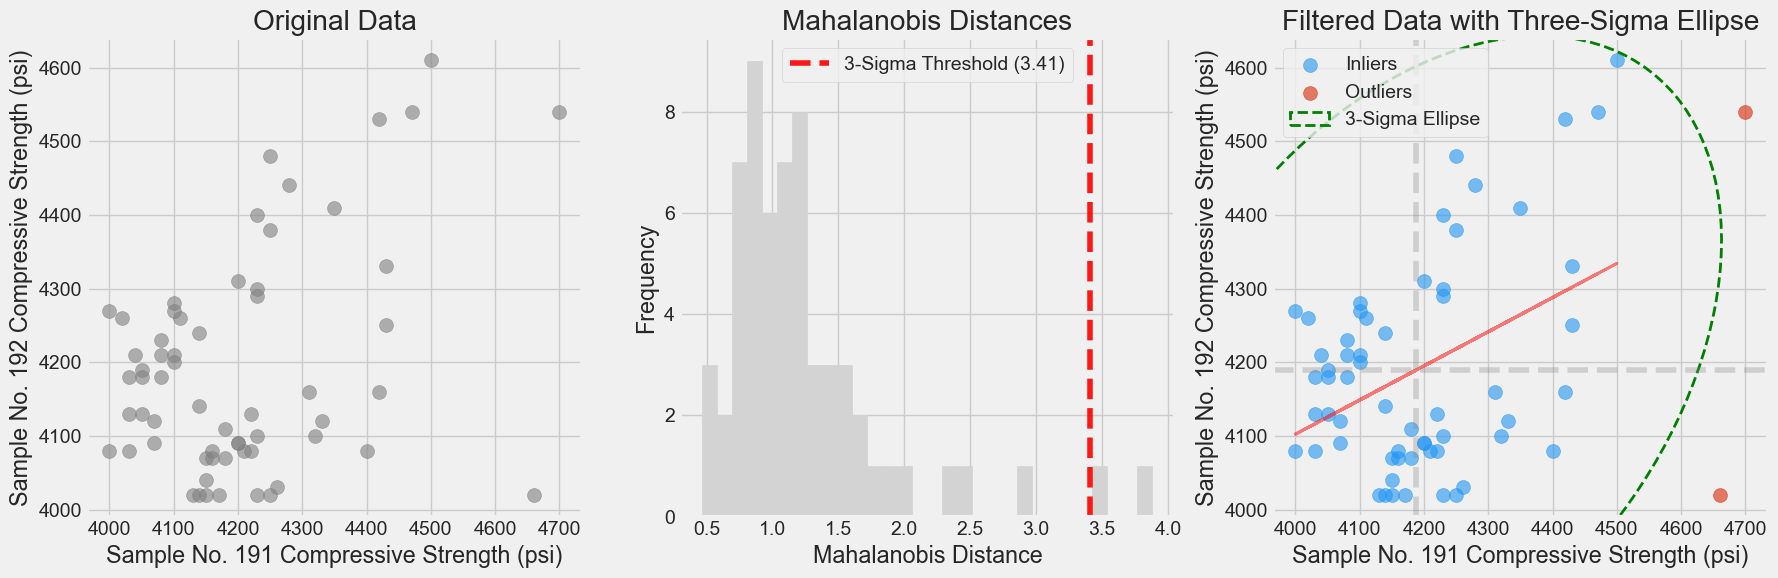

In [8]:
class MahalanobisFilter:
    """Detects outliers using Mahalanobis distance."""

    def __init__(self, alpha: float = 0.05):
        """Initialize with significance level alpha (default 0.05)"""
        self.alpha = alpha

    def fit(self, X: pd.DataFrame):
        """Calculate mean and inverse covariance matrix from data"""
        self.mean = np.mean(X, axis=0)
        self.cov = np.cov(X, rowvar=False)
        self.inv_cov = np.linalg.inv(self.cov)

    def mahalanobis_distance(self, x: np.ndarray) -> float:
        """Calculate Mahalanobis distance for a single point"""
        return mahalanobis(x, self.mean, self.inv_cov)

    def filter(
        self, X: pd.DataFrame, margin: float = 1e-5
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Filter data into inliers and outliers based on Mahalanobis distance
        relative to a three-sigma threshold.
        Returns (inliers, outliers) as DataFrames.
        """
        # Calculate distances and three-sigma threshold
        distances = np.array([self.mahalanobis_distance(point) for point in X.values])
        threshold_distance = (
            np.sqrt(chi2.ppf(0.997, df=X.shape[1])) + margin
        )  # 3-sigma threshold with margin

        # Split data
        inlier_indices = distances <= threshold_distance
        outlier_indices = distances > threshold_distance

        return X[inlier_indices], X[outlier_indices]


# ===== Data Processing =====


def process_data(data: pd.DataFrame) -> pd.DataFrame:
    """Extract and pair non-null samples from raw data"""
    processed_data = []
    for _, row in data.iterrows():
        sample1 = row["Sample 1"] if not pd.isna(row["Sample 1"]) else None
        sample2 = row["Sample 2"] if not pd.isna(row["Sample 2"]) else None
        if sample1 is not None and sample2 is not None:
            processed_data.append({"Sample 191": sample1, "Sample 192": sample2})
    return pd.DataFrame(processed_data)


# ===== Visualization =====


def plot_ellipse(
    mean: np.ndarray,
    cov: np.ndarray,
    ax: plt.Axes = None,
    n_std: float = 3.0,
    facecolor: str = "none",
    **kwargs,
) -> None:
    """
    Plot an n-standard deviation ellipse based on a 2D Gaussian distribution.

    Parameters:
        mean (array-like): The mean vector of the distribution (2,)
        cov (array-like): The covariance matrix of the distribution (2, 2)
        ax (matplotlib.axes.Axes, optional): The axis to plot the ellipse on. Defaults to None.
        n_std (float, optional): The number of standard deviations to determine the ellipse's radius. Defaults to 3.0.
        facecolor (str, optional): Color inside the ellipse. Defaults to "none".
        kwargs: Additional keyword arguments for the Ellipse patch
    """
    ax = plt.gca() if ax is None else ax

    mean = np.array(mean) if not isinstance(mean, np.ndarray) else mean
    cov = np.array(cov) if not isinstance(cov, np.ndarray) else cov

    if mean.shape != (2,):
        raise ValueError("Mean must be a 2-element array")
    if cov.shape != (2, 2):
        raise ValueError("Covariance matrix must be a 2x2 array")

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean, width=width, height=height, angle=angle, facecolor=facecolor, **kwargs
    )
    ax.add_patch(ellipse)


def create_plots(
    data: pd.DataFrame,
    inliers: pd.DataFrame,
    outliers: pd.DataFrame,
    alpha: float = 0.05,
    save_graph: bool = False,
) -> None:
    """Create three analysis plots: original data, distance histogram, and filtered results with ellipse"""
    plt.style.use("fivethirtyeight")
    _, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Original scatter plot
    axes[0].scatter(
        data["Sample 191"], data["Sample 192"], color="gray", alpha=0.6, s=100
    )
    axes[0].set_title("Original Data")
    axes[0].set_xlabel("Sample No. 191 Compressive Strength (psi)")
    axes[0].set_ylabel("Sample No. 192 Compressive Strength (psi)")

    # 2. Mahalanobis distance histogram
    m_filter = MahalanobisFilter(alpha=alpha)
    m_filter.fit(data)
    distances = np.array(
        [m_filter.mahalanobis_distance(point) for point in data.values]
    )
    threshold_distance = np.sqrt(chi2.ppf(0.997, df=data.shape[1]))  # 3-sigma threshold

    axes[1].hist(distances, bins=30, color="lightgray", edgecolor="lightgray")
    axes[1].axvline(
        x=threshold_distance,
        color="red",
        linestyle="--",
        alpha=0.9,
        label=f"3-Sigma Threshold ({threshold_distance:.2f})",
    )
    axes[1].set_title("Mahalanobis Distances")
    axes[1].set_xlabel("Mahalanobis Distance")
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    # 3. Filtered results with regression line and ellipse
    axes[2].scatter(
        inliers["Sample 191"],
        inliers["Sample 192"],
        color="#2196F3",
        alpha=0.6,
        s=100,
        label="Inliers",
    )
    axes[2].scatter(
        outliers["Sample 191"],
        outliers["Sample 192"],
        color="#D92906",
        alpha=0.6,
        s=100,
        label="Outliers",
    )

    # Add regression line
    m, b = np.polyfit(inliers["Sample 191"], inliers["Sample 192"], 1)
    axes[2].plot(
        inliers["Sample 191"],
        m * inliers["Sample 191"] + b,
        color="red",
        linestyle="-",
        alpha=0.5,
        linewidth=2,
    )

    # Add mean reference lines
    mean_x = inliers["Sample 191"].mean()
    mean_y = inliers["Sample 192"].mean()
    axes[2].axvline(x=mean_x, color="gray", linestyle="--", alpha=0.3)
    axes[2].axhline(y=mean_y, color="gray", linestyle="--", alpha=0.3)

    # Add three-sigma ellipse
    # Note 11-02-24: We commented this to use m_filter instead using the mean and covariance of the sample data
    # I think this give consistent visuals, inliers inside the 3-sigma ellipse and outliers showing
    # red scatter plot
    # mean = inliers[["Sample 191", "Sample 192"]].mean().values
    # cov = np.cov(inliers[["Sample 191", "Sample 192"]].values, rowvar=False)

    plot_ellipse(
        mean=m_filter.mean,
        cov=m_filter.cov,
        ax=axes[2],
        n_std=3,
        edgecolor="green",
        linestyle="--",
        linewidth=2,
        label="3-Sigma Ellipse",
    )

    axes[2].set_title("Filtered Data with Three-Sigma Ellipse")
    axes[2].set_xlabel("Sample No. 191 Compressive Strength (psi)")
    axes[2].set_ylabel("Sample No. 192 Compressive Strength (psi)")
    axes[2].legend(loc='upper left')
    # Save image
    if save_graph:
        plt.savefig(
            "images/combined_graph.png",
            dpi=300,
            bbox_inches="tight",
        )
    plt.tight_layout()
    plt.show()


# Run main
if __name__ == "__main__":
    # Load and process data
    data = df_sample  # Replace with your DataFrame containing the sample data
    processed_data = process_data(data)

    # Filter outliers based on Mahalanobis distance using a 3-sigma threshold
    filter_obj = MahalanobisFilter(alpha=0.05)
    filter_obj.fit(processed_data)
    inliers, outliers = filter_obj.filter(processed_data)

    # Visualize results
    create_plots(processed_data, inliers, outliers, save_graph=True, alpha=0.05)

# Filtered Plot Function
#### This function creates a visualization of the filtered data, showing inliers and outliers with a regression line and reference lines.

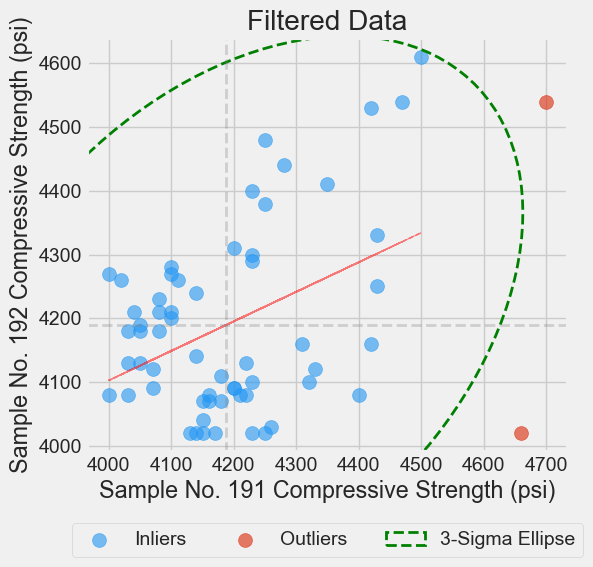

In [5]:
def create_filtered_plot(
    data: pd.DataFrame,
    inliers: pd.DataFrame,
    outliers: pd.DataFrame,
    save_graph: bool = False,
    alpha: float = 0.05,
) -> None:
    """Generates a scatter plot to visualize filtered data points, including inliers and outliers, along with a regression line and a 3-sigma ellipse.

    This function plots the inliers and outliers in a scatter plot, adds a regression line for the inliers, and includes mean reference lines and a 3-sigma ellipse to help identify the distribution of the inliers.

    Args:
        inliers (pd.DataFrame): DataFrame containing the inlier data points
        outliers (pd.DataFrame): DataFrame containing the outlier data points
        alpha (float, optional): Significance level for the Mahalanobis filter. Defaults to 0.05.
    """
    plt.style.use("fivethirtyeight")
    plt.figure(figsize=(6, 6))

    # Fit the Mahalanobis filter to the inliers to calculate the mean and covariance
    m_filter = MahalanobisFilter(alpha=alpha)
    m_filter.fit(data)

    # Plot inliers and outliers
    plt.scatter(
        inliers["Sample 191"],
        inliers["Sample 192"],
        color="#2196F3",
        alpha=0.6,
        s=100,
        label="Inliers",
    )
    plt.scatter(
        outliers["Sample 191"],
        outliers["Sample 192"],
        color="#D92906",
        alpha=0.6,
        s=100,
        label="Outliers",
    )

    # Add regression line for inliers
    m, b = np.polyfit(inliers["Sample 191"], inliers["Sample 192"], 1)
    plt.plot(
        inliers["Sample 191"],
        m * inliers["Sample 191"] + b,
        color="red",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )

    # Add mean reference lines
    plt.axvline(
        x=inliers["Sample 191"].mean(),
        color="gray",
        linestyle="--",
        linewidth=2,
        alpha=0.3,
    )
    plt.axhline(
        y=inliers["Sample 192"].mean(),
        color="gray",
        linestyle="--",
        linewidth=2,
        alpha=0.3,
    )

    # Add the 3-sigma ellipse
    plot_ellipse(
        mean=m_filter.mean,
        cov=m_filter.cov,
        n_std=3,
        edgecolor="green",
        linestyle="--",
        linewidth=2,
        label="3-Sigma Ellipse",
    )
    plt.title("Filtered Data")
    plt.xlabel("Sample No. 191 Compressive Strength (psi)")
    plt.ylabel("Sample No. 192 Compressive Strength (psi)")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

    # Save image
    if save_graph:
        plt.savefig(
            "images/isolated_graph_with_3_sigma_ellipse.png",
            dpi=300,
            bbox_inches="tight",
        )
    plt.tight_layout()
    plt.show()


# ## Example Usage
# Demonstrates how to use the filtering and plotting functions with sample data.

if __name__ == "__main__":
    data = df_sample
    processed_data = process_data(data)
    # Filter outliers
    filter_obj = MahalanobisFilter(alpha=0.05)
    filter_obj.fit(processed_data)
    inliers, outliers = filter_obj.filter(processed_data)

    # Create visualization
    create_filtered_plot(processed_data, inliers, outliers, save_graph=True, alpha=0.05)